In [3]:
!pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 2.7 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.7 MB 3.1 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.7 MB 3.0 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.7 MB 3.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.7 MB 3.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 3.9 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.7 MB 4.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.7 MB 4.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.7 MB 3.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.7 MB 3.7 MB/s eta 0:00:01
   ---------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\skate\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Tarea 1: Exploración de Niveles del Lenguaje


## 1. Fonética

In [2]:
import urllib.request
import difflib

# ==========================================
# 1. DESCARGAR Y CARGAR EL CORPUS (ipa-dict)
# ==========================================
print("Descargando el diccionario fonético desde GitHub...")
# Usamos el archivo de la variante mexicana
url = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/es_MX.txt"

# Añadimos un User-Agent para evitar bloqueos de GitHub
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
respuesta = urllib.request.urlopen(req)
lineas = respuesta.read().decode('utf-8').splitlines()

lexico_fonetico = {}
for linea in lineas:
    # El corpus separa la palabra de la transcripción con un tabulador (\t)
    partes = linea.split('\t')
    if len(partes) >= 2:
        palabra = partes[0].strip().lower()
        transcripcion = partes[1].strip()
        lexico_fonetico[palabra] = transcripcion

print(f"¡Listo! Se cargaron {len(lexico_fonetico)} palabras en el diccionario.\n")

# ==========================================
# 2. FUNCIÓN PARA PALABRAS OOV (Fuera del diccionario)
# ==========================================
def obtener_fonologia_aproximada(palabra_buscada, lexico):
    palabra_buscada = palabra_buscada.lower()
    
    # Caso 1: La palabra sí existe en el diccionario
    if palabra_buscada in lexico:
        return f"✅ Exacta: /{lexico[palabra_buscada]}/"
    
    # Caso 2: OOV - Buscamos la aproximación ortográfica más cercana
    similares = difflib.get_close_matches(palabra_buscada, lexico.keys(), n=1, cutoff=0.7)
    
    if similares:
        palabra_aproximada = similares[0]
        return f"⚠️ '{palabra_buscada}' (OOV). Aproximando a '{palabra_aproximada}': /{lexico[palabra_aproximada]}/"
    else:
        return f"❌ No se encontró '{palabra_buscada}' ni ninguna aproximación cercana."

# ==========================================
# 3. MOSTRAR LOS 3 EJEMPLOS SOLICITADOS
# ==========================================
print("--- EJEMPLOS SOLICITADOS EN LA TAREA ---")

# Ejemplo 1: Una pequeña falta de ortografía o error de dedo
print("Ejemplo 1 (Error de dedo):")
print(obtener_fonologia_aproximada("computadoa", lexico_fonetico))
print("-" * 50)

# Ejemplo 2: Un error ortográfico común
print("Ejemplo 2 (Error ortográfico):")
print(obtener_fonologia_aproximada("baca", lexico_fonetico)) 
print("-" * 50)

# Ejemplo 3: Letras repetidas o deformación de la palabra
print("Ejemplo 3 (Palabra deformada):")
print(obtener_fonologia_aproximada("murcieeelago", lexico_fonetico))
print("-" * 50)

Descargando el diccionario fonético desde GitHub...
¡Listo! Se cargaron 595885 palabras en el diccionario.

--- EJEMPLOS SOLICITADOS EN LA TAREA ---
Ejemplo 1 (Error de dedo):
⚠️ 'computadoa' (OOV). Aproximando a 'computadora': //komputaðoɾa//
--------------------------------------------------
Ejemplo 2 (Error ortográfico):
✅ Exacta: //baka//
--------------------------------------------------
Ejemplo 3 (Palabra deformada):
⚠️ 'murcieeelago' (OOV). Aproximando a 'murciélago': //muˈɾsjelaɣo//
--------------------------------------------------


## 2. Morfología

Descargando datos del corpus oficial...
RESULTADOS DE LOS CÁLCULOS:

--- Italiano ---
Ratio Morfemas / Palabra: 2.68
Índice Flexión (100): 41.63% | Índice Derivación (010): 0.00%

--- Ruso ---
Ratio Morfemas / Palabra: 3.85
Índice Flexión (100): 28.28% | Índice Derivación (010): 0.00%

--- Checo ---
Ratio Morfemas / Palabra: nan
Índice Flexión (100): 0.00% | Índice Derivación (010): 0.00%



C:\Users\skate\AppData\Local\Temp\ipykernel_12404\3754719204.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_morf_total, x='Lengua', y='longitud', ax=axes[0], palette="pastel")


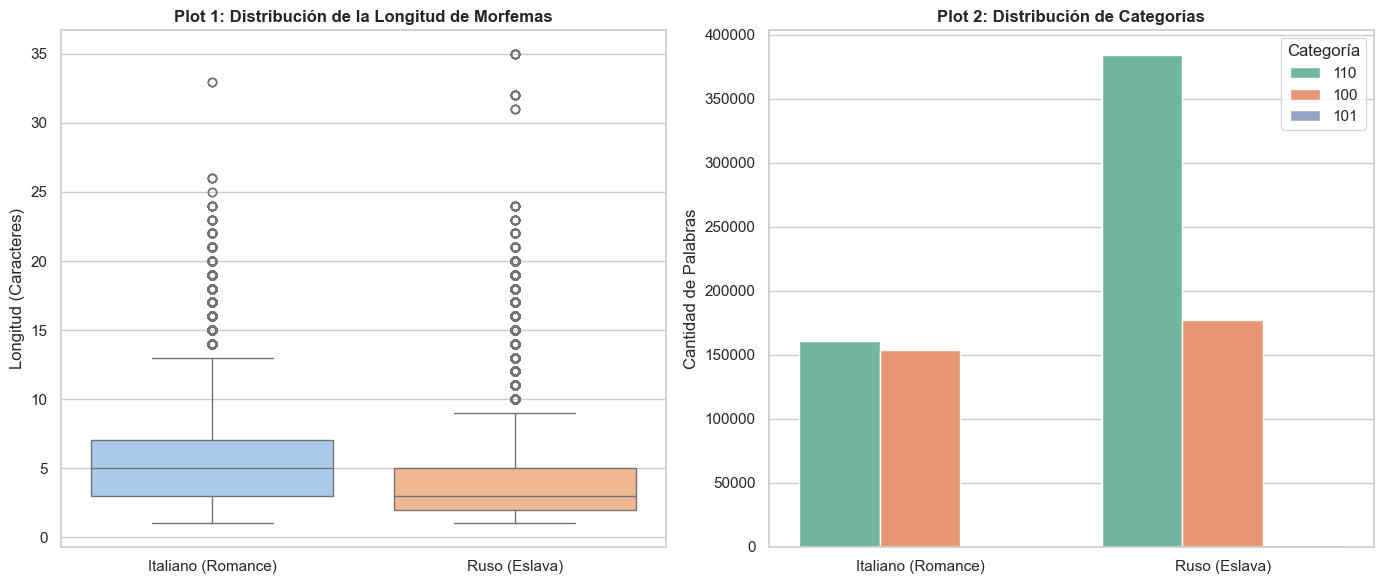

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARGA DEL CORPUS (SIGMORPHON 2022)
# ==========================================
print("Descargando datos del corpus oficial...")

# Usamos Italiano, Ruso y Checo (ramas Romance y Eslava)
df_ita = pd.read_csv('https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/master/data/ita.word.train.tsv', sep='\t', names=['palabra', 'segmentacion', 'etiqueta'])
df_rus = pd.read_csv('https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/master/data/rus.word.train.tsv', sep='\t', names=['palabra', 'segmentacion', 'etiqueta'])
df_ces = pd.read_csv('https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/master/data/ces.word.train.tsv', sep='\t', names=['palabra', 'segmentacion', 'etiqueta'])

df_ita['Lengua'] = 'Italiano (Romance)'
df_rus['Lengua'] = 'Ruso (Eslava)'
df_ces['Lengua'] = 'Checo (Eslava)'

# ==========================================
# 2. CÁLCULOS: Ratio e Índices
# ==========================================
def analizar_sigmorphon(df, nombre_lengua):
    df = df.dropna(subset=['segmentacion', 'etiqueta']).copy()
    
    # SOLUCIÓN APLICADA: Usamos .str.len() en lugar de .apply(len)
    df['num_morfemas'] = df['segmentacion'].astype(str).str.split(' ').str.len()
    ratio = df['num_morfemas'].mean()
    
    df['etiqueta'] = df['etiqueta'].astype(str).str.strip()
    total_palabras = len(df)
    
    # Evitamos la división por cero por si algún DataFrame viene filtrado
    flexion = len(df[df['etiqueta'] == '100']) / total_palabras * 100 if total_palabras > 0 else 0
    derivacion = len(df[df['etiqueta'] == '010']) / total_palabras * 100 if total_palabras > 0 else 0
    
    print(f"--- {nombre_lengua} ---")
    print(f"Ratio Morfemas / Palabra: {ratio:.2f}")
    print(f"Índice Flexión (100): {flexion:.2f}% | Índice Derivación (010): {derivacion:.2f}%\n")
    
    morfemas_individuales = []
    for _, row in df.iterrows():
        segmentos = str(row['segmentacion']).split(' ')
        for seg in segmentos:
            morfema_limpio = seg.replace('@@', '') 
            if len(morfema_limpio) > 0:
                morfemas_individuales.append({
                    'Lengua': row['Lengua'],
                    'morfema': morfema_limpio,
                    'longitud': len(morfema_limpio)
                })
            
    return df, pd.DataFrame(morfemas_individuales)

print("RESULTADOS DE LOS CÁLCULOS:\n")
df_ita, df_morf_ita = analizar_sigmorphon(df_ita, "Italiano")
df_rus, df_morf_rus = analizar_sigmorphon(df_rus, "Ruso")
df_ces, df_morf_ces = analizar_sigmorphon(df_ces, "Checo")

df_total = pd.concat([df_ita, df_rus, df_ces])
df_morf_total = pd.concat([df_morf_ita, df_morf_rus, df_morf_ces])

# ==========================================
# 3. VISUALIZACIÓN (Subplots)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_morf_total, x='Lengua', y='longitud', ax=axes[0], palette="pastel")
axes[0].set_title('Plot 1: Distribución de la Longitud de Morfemas', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Longitud (Caracteres)')
axes[0].set_xlabel('')

orden_etiquetas = ['100', '010', '000', '110', '101']
df_filtrado = df_total[df_total['etiqueta'].isin(orden_etiquetas)]

sns.countplot(data=df_filtrado, x='Lengua', hue='etiqueta', ax=axes[1], palette="Set2")
axes[1].set_title('Plot 2: Distribución de Categorías', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cantidad de Palabras')
axes[1].set_xlabel('')
axes[1].legend(title='Categoría')

plt.tight_layout()
plt.show()